In [2]:
from nilearn.plotting import plot_roi, plot_surf_roi
from nilearn import datasets, surface

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage7")
dataset_yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)
# plot_roi(
#     dataset_yeo.maps,
#     title="Yeo atlas",
#     colorbar=True,
#     display_mode="z"
# )

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011

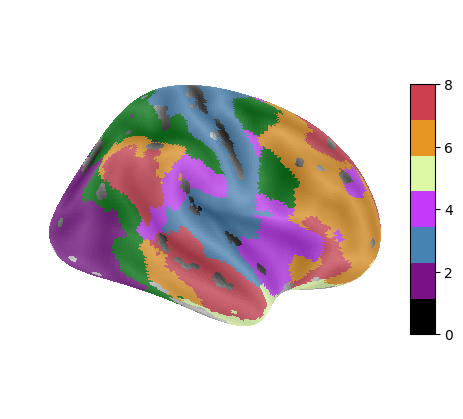

In [3]:
from nilearn.datasets import load_fsaverage_data
from nilearn import datasets, surface, plotting
import numpy as np
from matplotlib import pyplot as plt

fsaverage = datasets.load_fsaverage()
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)

# Project to surface with nearest-neighbor (no blurring)
labels_left = surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['left'], interpolation="nearest_most_frequent"
)
labels_right =  surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['right'], interpolation="nearest_most_frequent"
)

fsaverage_sulcal = load_fsaverage_data(data_type="sulcal")

# labels_left[labels_left == 0] = np.nan
# labels_left += 1
# 
# # Plot
# fig = plot_surf_roi(
#   fsaverage['inflated'].parts["left"],
#   roi_map=labels_left,
#   hemi="left",
#   view="lateral",
#     cmap=dataset_yeo.lut,
#   colorbar=True,
#     bg_map=fsaverage_sulcal,
#     bg_on_data=True,
#     darkness=None,
# )

labels_left[labels_left == 0] = np.nan
labels_right[labels_right == 0] = np.nan

labels =  {
    "left": labels_left,
    "right": labels_right,
}
hemi = "right"
fig = plotting.plot_surf_roi(
  fsaverage['inflated'].parts[hemi],
  roi_map=labels[hemi],
  hemi=hemi,
  view="lateral",
  cmap=dataset_yeo.lut,
  vmin=0,
  vmax=8,
  colorbar=True,
  bg_map=fsaverage_sulcal,
  bg_on_data=True,
  darkness=None,
)
plt.savefig(f"/Users/zach/2025_RA/matthias/final images/FC/{hemi}_yeo.png", dpi=300)

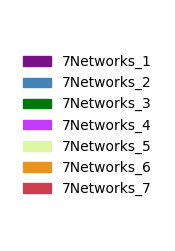

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

colors = yeo.lut["color"].tolist()[1:]  # skip background (0)
labels = yeo.lut["name"].tolist()[1:]

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
fig, ax = plt.subplots(figsize=(2, 3))
ax.legend(handles=patches, loc="center", frameon=False)
ax.axis("off")
plt.savefig('/Users/zach/2025_RA/matthias/final images/FC/colorbar.svg', dpi=300)
plt.show()


In [ ]:
yeo.lut

In [ ]:
from matplotlib import cm

from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(0.3, 3))
cb = fig.colorbar(
  cm.ScalarMappable(norm=Normalize(-1, 1), cmap="bwr"),
  cax=ax,
)
cb.set_ticks([])
cb.set_label("← negative FC    positive FC →", fontsize=8)
plt.savefig('/Users/zach/2025_RA/matthias/final images/FC/FCcolorbar_n.svg', bbox_inches="tight")

In [ ]:
Now 
"""
0 - black = background
1 - purple = visual 
2 - blue = somatamotor
3 - green = dorsal attention
4 - violet = vental attention
5 - cream = limbic 
6 - orange = frontoparietal 
7 - red = default
"""
import numpy as np
import pandas as pd

# yeo.lut has the label-to-color mapping
print(yeo.lut)

In [1]:
import nib

ho_sub_label_to_region = {
       # White matter
    "Left Cerebral White Matter":  "WhiteMatter",
    "Right Cerebral White Matter": "WhiteMatter",

    # Extremely broad hemispheric cortex masks (often excluded)
    "Left Cerebral Cortex":  "Cortex",
    "Right Cerebral Cortex": "Cortex",

    # Ventricles (CSF)
    "Left Lateral Ventricle":  "Ventricle",
    "Right Lateral Ventricle": "Ventricle",

    # Thalamus
    "Left Thalamus":  "Thalamus",
    "Right Thalamus": "Thalamus",

    # Basal ganglia / ventral striatum
    "Left Caudate":    "BasalGanglia",
    "Right Caudate":   "BasalGanglia",
    "Left Putamen":    "BasalGanglia",
    "Right Putamen":   "BasalGanglia",
    "Left Pallidum":   "BasalGanglia",
    "Right Pallidum":  "BasalGanglia",
    "Left Accumbens":  "BasalGanglia",
    "Right Accumbens": "BasalGanglia",

    # Hippocampus
    "Left Hippocampus":  "Hippocampus",
    "Right Hippocampus": "Hippocampus",

    # Amygdala
    "Left Amygdala":  "Amygdala",
    "Right Amygdala": "Amygdala",

    # Brainstem
    "Brain-Stem": "Brainstem",
}
ho_sub_order = [
    "Hippocampus","Amygdala","Thalamus","Hypothalamus",
    "BasalGanglia","Brainstem"
]

ho_label_to_region = {
    'Frontal Pole': 'Frontal',
    'Superior Frontal Gyrus': 'Frontal',
    'Middle Frontal Gyrus': 'Frontal',
    'Inferior Frontal Gyrus, pars triangularis': 'Frontal',
    'Inferior Frontal Gyrus, pars opercularis': 'Frontal',
    'Precentral Gyrus': 'Frontal',
    'Frontal Medial Cortex': 'Frontal',
    'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)': 'Frontal',
    'Frontal Orbital Cortex': 'Frontal',
    'Frontal Opercular Cortex': 'Frontal',
    'Temporal Pole': 'Temporal',
    'Superior Temporal Gyrus, anterior division': 'Temporal',
    'Superior Temporal Gyrus, posterior division': 'Temporal',
    'Middle Temporal Gyrus, anterior division': 'Temporal',
    'Middle Temporal Gyrus, posterior division': 'Temporal',
    'Middle Temporal Gyrus, temporooccipital part': 'Temporal',
    'Inferior Temporal Gyrus, anterior division': 'Temporal',
    'Inferior Temporal Gyrus, posterior division': 'Temporal',
    'Inferior Temporal Gyrus, temporooccipital part': 'Temporal',
    'Parahippocampal Gyrus, anterior division': 'Temporal',
    'Parahippocampal Gyrus, posterior division': 'Temporal',
    'Temporal Fusiform Cortex, anterior division': 'Temporal',
    'Temporal Fusiform Cortex, posterior division': 'Temporal',
    'Temporal Occipital Fusiform Cortex': 'Temporal',
    'Planum Polare': 'Temporal',
    "Heschl's Gyrus (includes H1 and H2)": 'Temporal',
    'Planum Temporale': 'Temporal',
    'Postcentral Gyrus': 'Parietal',
    'Superior Parietal Lobule': 'Parietal',
    'Supramarginal Gyrus, anterior division': 'Parietal',
    'Supramarginal Gyrus, posterior division': 'Parietal',
    'Angular Gyrus': 'Parietal',
    'Precuneous Cortex': 'Parietal',
    'Parietal Opercular Cortex': 'Parietal',
    'Lateral Occipital Cortex, superior division': 'Occipital',
    'Lateral Occipital Cortex, inferior division': 'Occipital',
    'Intracalcarine Cortex': 'Occipital',
    'Cuneal Cortex': 'Occipital',
    'Lingual Gyrus': 'Occipital',
    'Occipital Fusiform Gyrus': 'Occipital',
    'Supracalcarine Cortex': 'Occipital',
    'Occipital Pole': 'Occipital',
    'Subcallosal Cortex': 'Cingulate',
    'Paracingulate Gyrus': 'Cingulate',
    'Cingulate Gyrus, anterior division': 'Cingulate',
    'Cingulate Gyrus, posterior division': 'Cingulate',
    'Central Opercular Cortex': 'Insula',
    'Insular Cortex': 'Insula',
}

ho_order =  ["Frontal", "Parietal", "Temporal", "Occipital", "Cingulate",
               "Insula",]


juelich_label_to_region = {
    # --- Amygdala nuclei ---
    "GM Amygdala_centromedial group": "Amygdala",
    "GM Amygdala_laterobasal group": "Amygdala",
    "GM Amygdala_superficial group": "Amygdala",

    # --- Parietal (intra-parietal sulcus) ---
    "GM Anterior intra-parietal sulcus hIP1": "Parietal",
    "GM Anterior intra-parietal sulcus hIP2": "Parietal",
    "GM Anterior intra-parietal sulcus hIP3": "Parietal",

    # --- Frontal ---
    "GM Broca's area BA44": "Frontal",
    "GM Broca's area BA45": "Frontal",
    "GM Premotor cortex BA6": "Frontal",
    "GM Primary motor cortex BA4a": "Frontal",
    "GM Primary motor cortex BA4p": "Frontal",

    # --- Hippocampus & related ---
    "GM Hippocampus cornu ammonis": "Hippocampus",
    "GM Hippocampus dentate gyrus": "Hippocampus",
    "GM Hippocampus entorhinal cortex": "Hippocampus",
    "GM Hippocampus hippocampal-amygdaloid transition area": "Hippocampus",
    "GM Hippocampus subiculum": "Hippocampus",

    # --- Inferior parietal lobule ---
    "GM Inferior parietal lobule PF": "Parietal",
    "GM Inferior parietal lobule PFcm": "Parietal",
    "GM Inferior parietal lobule PFm": "Parietal",
    "GM Inferior parietal lobule PFop": "Parietal",
    "GM Inferior parietal lobule PFt": "Parietal",
    "GM Inferior parietal lobule PGp": "Parietal",
    "GM Inferior parietal lobule Pga": "Parietal",

    # --- Insula ---
    "GM Insula Id1": "Insula",
    "GM Insula Ig1": "Insula",
    "GM Insula Ig2": "Insula",

    # --- Thalamus (geniculate nuclei) ---
    "GM Lateral geniculate body": "Thalamus",
    "GM Medial geniculate body": "Thalamus",

    # --- Hypothalamus ---
    "GM Mamillary body": "Hypothalamus",

    # --- Auditory cortex ---
    "GM Primary auditory cortex TE1.0": "Temporal",
    "GM Primary auditory cortex TE1.1": "Temporal",
    "GM Primary auditory cortex TE1.2": "Temporal",

    # --- Somatosensory cortex ---
    "GM Primary somatosensory cortex BA1": "Parietal",
    "GM Primary somatosensory cortex BA2": "Parietal",
    "GM Primary somatosensory cortex BA3a": "Parietal",
    "GM Primary somatosensory cortex BA3b": "Parietal",

    # --- Secondary somatosensory / operculum ---
    "GM Secondary somatosensory cortex / Parietal operculum OP1": "Parietal",
    "GM Secondary somatosensory cortex / Parietal operculum OP2": "Parietal",
    "GM Secondary somatosensory cortex / Parietal operculum OP3": "Parietal",
    "GM Secondary somatosensory cortex / Parietal operculum OP4": "Parietal",

    # --- Superior parietal lobule ---
    "GM Superior parietal lobule 5Ci": "Parietal",
    "GM Superior parietal lobule 5L": "Parietal",
    "GM Superior parietal lobule 5M": "Parietal",
    "GM Superior parietal lobule 7A": "Parietal",
    "GM Superior parietal lobule 7M": "Parietal",
    "GM Superior parietal lobule 7P": "Parietal",
    "GM Superior parietal lobule 7PC": "Parietal",

    # --- Visual cortex ---
    "GM Visual cortex V1 BA17": "Occipital",
    "GM Visual cortex V2 BA18": "Occipital",
    "GM Visual cortex V3V": "Occipital",
    "GM Visual cortex V4": "Occipital",
    "GM Visual cortex V5": "Occipital",

    # --- White matter tracts ---
    "WM Acoustic radiation": "WhiteMatter",
    "WM Callosal body": "WhiteMatter",
    "WM Cingulum": "WhiteMatter",
    "WM Corticospinal tract": "WhiteMatter",
    "WM Fornix": "WhiteMatter",
    "WM Inferior occipito-frontal fascicle": "WhiteMatter",
    "WM Optic radiation": "WhiteMatter",
    "WM Superior longitudinal fascicle": "WhiteMatter",
    "WM Superior occipito-frontal fascicle": "WhiteMatter",
    "WM Uncinate fascicle": "WhiteMatter",
}

juelich_order =  ["Frontal", "Parietal", "Temporal", "Occipital", "Cingulate",
               "Insula", "Amygdala", "Hippocampus", "Thalamus", "Hypothalamus", "WhiteMatter"]



order_map = {
    "juelich": juelich_order,
    "ho": ho_order,
    "ho_sub": ho_sub_order
}

group_map = {
    "juelich": juelich_label_to_region,
    "ho": ho_label_to_region,
    "ho_sub": ho_sub_label_to_region,
}

In [2]:
import re
from nilearn import datasets

atlases = {
    "juelich": datasets.fetch_atlas_juelich('maxprob-thr25-2mm'),
    "ho": datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm"),
    "ho_sub": datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm"),
    "schaefer500": datasets.fetch_atlas_schaefer_2018(n_rois=500, yeo_networks=7),
    "aal": datasets.fetch_atlas_aal(),
}

schaefer_groups = {}
for label in atlases["schaefer500"].labels:
    if label in ("Background", "???"):
        continue
    # Split the label, format: "LH_Vis_1"
    parts = label.split('_')
    if len(parts) >= 3:
        hemi, network, idx = parts[1], parts[2], parts[3]
        schaefer_groups[label] = network
    else:
        schaefer_groups[label] = None  # fallback
group_map["schaefer500"] = schaefer_groups
schaefer_order = ['Vis', 'Cont', 'DorsAttn', 'Default',  'SomMot', 'SalVentAttn',  'Limbic']
order_map["schaefer500"] = schaefer_order
# print(set(schaefer_groups.values()))

def aal_group(label: str) -> str:
    # strip side/number suffixes (e.g. _L/_R or _1)
    stem = re.sub(r'_(L|R|\d+)$', '', label)

    # --- lobe / system buckets ---
    if stem.startswith(("Frontal", "Precentral", "Supp_Motor_Area",
                        "Olfactory", "Rectus", "Frontal_Med_Orb",
                        "Paracentral_Lobule")):
        return "Frontal"
    if stem.startswith(("Postcentral", "Parietal", "SupraMarginal",
                        "Angular", "Precuneus")):
        return "Parietal"
    if stem.startswith(("Occipital", "Calcarine", "Cuneus",
                        "Lingual", "Fusiform")):
        return "Occipital"
    if stem.startswith(("Temporal", "Heschl")):
        return "Temporal"
    if stem.startswith(("Insula", "Rolandic_Oper")):
        return "Insula"
    if stem.startswith(("Cingulum", "ParaHippocampal",
                        "Hippocampus", "Amygdala")):
        return "Limbic / Cingulate"
    if stem.startswith(("Thalamus", "Caudate", "Putamen",
                        "Pallidum", "Accumbens")):
        return "Subcortical"
    if stem.startswith(("Cerebelum", "Cerebellum", "Vermis")):
        return "Cerebellum"
    return "Other"

# aal_groups = {lbl: aal_group(lbl) for lbl in atlases["aal"].labels}
# group_map["aal"] = aal_groups
# order_map["aal"] = ["Frontal", "Parietal", "Temporal", "Occipital",
#                "Insula", "Limbic / Cingulate", "Subcortical", "Cerebellum"]
# 



[fetch_atlas_juelich] Dataset found in /Users/zach/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Dataset found in /Users/zach/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Dataset found in /Users/zach/nilearn_data/fsl

[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_83514/3590462514.py:9: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  "aal": datasets.fetch_atlas_aal(),


[fetch_atlas_aal] Dataset found in /Users/zach/nilearn_data/aal_SPM12

In [3]:

from pathlib import Path
from typing import Iterable
from scipy.stats import ttest_1samp, false_discovery_control
import pandas as pd

import numpy as np 

def vec_upper(mat):
    upper_tri_indices = np.triu_indices_from(mat, k=1)
    return mat[upper_tri_indices], upper_tri_indices

def vecs_from_mats(subj_mats):
    """
    Extract upper triangle of edges (without diagonal) as a 1D vector for each matrix 
    and return as a matrix (n_subjs, n_edges)
    :param subj_mats: 
    :return: 
    """
    # mats: array (n_subj, n_roi, n_roi) or list of (n_roi, n_roi)
    first = subj_mats[0]
    _, upper_tri_indices = vec_upper(first)
    V = np.vstack([m[upper_tri_indices] for m in subj_mats])  # (n_subj, n_edges)
    return V, upper_tri_indices

def mat_from_vec(v, n_rois):
    M = np.zeros((n_rois, n_rois), dtype=float)
    iu = np.triu_indices(n_rois, 1)
    M[iu] = v
    M[(iu[1], iu[0])] = v
    return M

def fc_paired_test(z_mats_A, z_mats_B, alpha=0.05, return_mats=True, alternative="greater", n_permutations=10000, seed=42):
    """
    Inputs:
      z_mats_A / z_mats_B: arrays of Fisher-z FC matrices with shape (n_subj, n_roi, n_roi)
    Returns:
      dict/DataFrame with edge-wise stats (+ optional matrix forms)
    """
    rng = np.random.default_rng(seed)
    A = np.asarray(z_mats_A)
    B = np.asarray(z_mats_B)
    assert A.shape == B.shape, f"Shape mismatch: {A.shape} vs {B.shape}"
    n_subj, n_roi, _ = A.shape

    VA, iu = vecs_from_mats(A)
    VB, _  = vecs_from_mats(B)
    D = VA - VB  # (n_subj, n_edges)
    mean_diff = np.nanmean(D, axis=0)
    # print(D.shape)
    
    # One-sample t against 0 on edge-wise diffs (two-sided by default)
    # tvals, pvals = ttest_1samp(D, popmean=0.0, axis=0, alternative=alternative)
    
    # Sign-flipping null distribution
    n_edges = D.shape[1]
    count = np.zeros(n_edges, dtype=np.int32)
    
    chunk_size = 1
    for start in range(0, n_permutations, chunk_size):
        signs_chunk = rng.choice([-1, 1], size=(chunk_size, n_subj)).astype(np.float32)  # shape: (1, n_subj)
        chunk_means = np.dot(signs_chunk, D) / n_subj
        # chunk_means = (signs_chunk @ D) / n_subj  # (chunk, n_edges)
        # 
        if alternative == "two-sided":
            count += (np.abs(chunk_means) >= np.abs(mean_diff)).sum(axis=0)
        elif alternative == "greater":
            count += (chunk_means >= mean_diff).sum(axis=0)
        else:  # less
            count += (chunk_means <= mean_diff).sum(axis=0)
    
    pvals = (count + 1) / (n_permutations + 1)
    # null_means = np.zeros((n_permutations, D.shape[1]))
    # signs = rng.choice([-1, 1], size=(n_permutations, n_subj))  # (n_perm, n_subj)
    # null_means = (signs @ D) / n_subj  # (n_perm, n_edges)
    #     # null_means[i] = np.nanmean(D * signs, axis=0)
    # 
    # # p-values
    # if alternative == "greater":
    #     pvals = (np.sum(null_means >= mean_diff, axis=0) + 1) / (n_permutations + 1)
    # elif alternative == "less":
    #     pvals = (np.sum(null_means <= mean_diff, axis=0) + 1) / (n_permutations + 1)
    # elif alternative == "two-sided":
    #     pvals = (np.sum(np.abs(null_means) >= np.abs(mean_diff), axis=0) + 1) / (n_permutations + 1)
    # else:
    #     raise ValueError(f"Unknown alternative: {alternative!r}")


    # FDR 
    pvals_fdr = false_discovery_control(pvals)
    sig = pvals_fdr <= alpha

    # Effect size on good edges
    sd = np.nanstd(D, axis=0, ddof=1)
    dz = mean_diff / sd
    dz[sd == 0] = np.nan

    out = {
        "iu": iu,
        "mean_diff_vec": mean_diff,
        "pvals_vec": pvals,
        "pvals_fdr_vec": pvals_fdr,
        "significant_vec": sig,
        "cohens_dz_vec": dz,
        "n_subj": n_subj,
        "n_roi": n_roi,
    }

    if return_mats:
        out.update({
            "pvals_mat": mat_from_vec(pvals, n_roi),
            "pvals_fdr_mat": mat_from_vec(pvals_fdr, n_roi),
            "sig_mat": mat_from_vec(sig.astype(float), n_roi),
            "mean_diff_mat": mat_from_vec(mean_diff, n_roi),
            "cohens_dz_mat": mat_from_vec(dz, n_roi),
        })

    i_row, i_col = iu
    df = pd.DataFrame({
        "roi_i": i_row,
        "roi_j": i_col,
        "p": pvals,
        "p_fdr": pvals_fdr,
        "sig_fdr": sig,
        "mean_diff_z": mean_diff,
        "cohens_dz": dz,
    })
    out["table"] = df
    return out


def remove_labels(A, B, labels: Iterable, remove_starts_with: Iterable | None = None, remove_any: Iterable | None = None):
    A = np.asarray(A)      # (n_subj, n_roi, n_roi)
    B = np.asarray(B)
    assert A.shape == B.shape, f"Shape mismatch: {A.shape} vs {B.shape}"
    n_subj, n_roi, _ = A.shape
    
    # Boolean mask for GM (exclude WM)
    # Normalize inputs
    prefixes = tuple(s.lower() for s in (remove_starts_with or ()) if s)
    subs = tuple(s.lower() for s in (remove_any or ()) if s)

    # Lowercased copy for comparisons (keeps originals intact)
    labels_lower = [lbl.lower() for lbl in labels]
    
    # startswith can take a tuple of prefixes
    starts_mask = np.array(
        [lbl.startswith(prefixes) if prefixes else False for lbl in labels_lower],
        dtype=bool
    )
    # Any forbidden substring present?
    contains_mask = np.array(
        [any(s in lbl for s in subs) if subs else False for lbl in labels_lower],
        dtype=bool
    )
    keep_mask = ~(starts_mask | contains_mask)
    masked_labels = [lbl for lbl, keep in zip(labels, keep_mask) if keep]
    
    g = np.flatnonzero(keep_mask)     # indices of GM ROIs
    
    # Slice rows and columns using the GM index list
    A_clean = A[:, g, :][:, :, g]    # shape (n_subj, new_n_roi, new_n_roi)
    B_clean = B[:, g, :][:, :, g]
    
    print(f"A: {A_clean.shape}, B: {B_clean.shape}")
    
    return A_clean, B_clean, masked_labels


def process_matrices(results_dir, atlas_name, state):
    atlas = atlases[atlas_name]
    labels = atlas.labels[1:] # Ignore background
    
    with_eds = np.load(results_dir / f"{atlas_name}_conv-and-unconv_{state}_with_eds.npy")
    without_eds = np.load(results_dir / f"{atlas_name}_conv-and-unconv_{state}_without_eds.npy")
    # print(str(extractor.data_dir / "FC" /  state / f"{atlas_name}_conv_with_eds.npy"))
     
    if atlas_name == "juelich":
        with_eds, without_eds, labels = remove_labels(with_eds, without_eds, labels, remove_starts_with={"WM "})
    elif atlas_name == "ho_sub":
        with_eds, without_eds, labels = remove_labels(with_eds, without_eds, labels, remove_any={"White Matter", "Cortex", "Ventricle"})
    
    return with_eds, without_eds, labels


_atlas_name = "schaefer500"

atlases_results = {}
results_dir = Path("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/results")
STATES = ["W","S","all"]
for atlas_name in atlases:
    if atlas_name != _atlas_name:
        continue
        
    for state in STATES:
        with_eds, without_eds, labels = process_matrices(results_dir, atlas_name, state)
        assert with_eds.shape == without_eds.shape
        _, n_roi, _ = with_eds.shape
        assert len(labels) == n_roi, f"Labels {len(labels)} vs n_roi {n_roi}"
        
        with_mean = np.mean(with_eds, axis=0)
        without_mean = np.mean(without_eds, axis=0) 
        ttest_res = fc_paired_test(without_eds, with_eds, return_mats=True, alternative="two-sided", n_permutations=10000) # Expect without to be greater
        
        print(state)
        print(ttest_res["sig_mat"].astype(int).sum())
        print("labels", len(labels))
        print(with_mean.shape)
        print("Background" in labels)
        
        atlases_results.setdefault(atlas_name, {}).setdefault("states", {})[state] = {
            "with_mean": with_mean,
            "without_mean": without_mean,
            "ttest_res": ttest_res
        }
        atlases_results[atlas_name]["labels"] = labels
 


W
610
labels 500
(500, 500)
False
S
4034
labels 500
(500, 500)
False
all
27012
labels 500
(500, 500)
False


In [4]:

# Plot the correlation matrix
from scipy.stats import rankdata
from nilearn import plotting

import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_matrix(
    mat,
    groups,
    group_order,
    roi_names=None,
    cmap="bwr",
    vlim=None,                 # None -> symmetric from visible data; scalar -> ±vlim; tuple -> (vmin, vmax)
    title=None,
    hide_diagonal=True,
    sig_mask=None,             # boolean NxN (True = keep)
    upper_triangle_masked=True,# top = sig-only, bottom = full
    ax=None,                   # <— NEW: draw into this axes if provided
    show_colorbar=False,        # <— NEW: you can add a shared CB outside
    rank=False,
    percentage=False,
):    
    N = mat.shape[0]
    # assert mat.shape[0] == mat.shape[1], "Matrix must be square"
    # assert len(groups) == N, f"groups length {len(groups)} != N {N}"
    if roi_names is None:
        roi_names = [f"ROI{i}" for i in range(N)]

    # order by group rank then roi name
    if len(groups) == N:
        grp_rank = {g: i for i, g in enumerate(group_order)}
        default_rank = len(group_order)
        order = sorted(range(N), key=lambda i: (grp_rank.get(groups[i], default_rank), roi_names[i]))
        groups_ord = [groups[i] for i in order]
        names_ord  = [roi_names[i] for i in order]
    else:
        order = range(N)
        groups_ord = ["" for _ in order]
        names_ord  = ["" for _ in order]

    mat_ord    = mat[np.ix_(order, order)].astype(float)

    sig_ord = None
    if sig_mask is not None:
        assert sig_mask.shape == mat.shape, "sig_mask must match mat shape"
        sig_ord = sig_mask[np.ix_(order, order)]
    

    # build display matrix
    M = mat_ord.copy()
    vmin, vmax = None, None
    if upper_triangle_masked and sig_ord is not None:
        
        M_plot = np.full_like(M, np.nan, dtype=float)
        iu = np.triu_indices_from(M, k=1)
        il = np.tril_indices_from(M, k=-1)
        sig_values =  np.where(sig_ord[iu], M[iu], np.nan) 
        M_plot[iu] = sig_values # upper: sig only
        # M_plot[iu] = np.where(sig_ord[iu] & (M[iu] < 0), M[iu], np.nan)  # upper: positive sig only
        M_plot[il] = M[il]                                  # lower: full
        
        # Figure out color thresholding
        vmin = np.min(np.abs(sig_values[sig_values < 0]))
        vmax = np.min(np.abs(sig_values[sig_values > 0]))
        
        print(f"vmin = {vmin}")
        print(f"vmax = {vmax}")
        
        # Print proportion of positive and negative significant edges
        iu = np.triu_indices_from(sig_mask, k=1)
        sig_edges = sig_mask[iu]
        diff_vals = M[iu]
        
        sig_pos = (sig_edges & (diff_vals > 0)).sum()
        sig_neg = (sig_edges & (diff_vals < 0)).sum()
        total_edges = sig_edges.sum()
        
        print(f"Total significant edges: {total_edges} / {len(sig_edges)}")
        print(f"Positive (FC higher without gaze reg): {sig_pos} ({sig_pos/len(sig_edges)*100:.1f}%)")
        print(f"Negative (FC higher with gaze reg): {sig_neg} ({sig_neg/len(sig_edges)*100:.1f}%)")

    else:
        M_plot = M

    if hide_diagonal:
        np.fill_diagonal(M_plot, np.nan)
    M_masked = np.ma.masked_invalid(M_plot)

    # group bounds
    bounds, centers, labels_out = [], [], []
    for g in group_order:
        idx = [i for i, gg in enumerate(groups_ord) if gg == g]
        if not idx:
            continue
        s, e = min(idx), max(idx) + 1
        bounds.append((s, e, g))
        centers.append((s + e - 1) / 2)
        labels_out.append(g)

    # plotting
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
        created_fig = True
    else:
        fig = ax.figure

    ax.grid(False)

    # im = ax.imshow(M_masked, cmap=cmap, vmin=vmin, vmax=vmax, origin="upper",
    #                interpolation="nearest", aspect="equal")
    if rank:
        finite_mask = np.isfinite(M_plot)
        M_ranked = np.full_like(M_plot, np.nan)
        M_ranked[finite_mask] = rankdata(M_plot[finite_mask])
        M_masked = np.ma.masked_invalid(M_ranked)
        
    # if vmin is not None and vmax is not None:
    #     vlim = max(vmin, vmax)
    # vlim = None
    im = ax.imshow(M_masked, vmin=-0.012, vmax=0.012, cmap=cmap, origin="upper",
                   interpolation="nearest", aspect="equal")
    
    # group grid lines and box
    for s, e, _ in bounds:
        ax.axhline(e - 0.5, color="k", lw=1)
        ax.axvline(e - 0.5, color="k", lw=1)
    ax.axhline(-0.5, color="k", lw=1); ax.axhline(N - 0.5, color="k", lw=1)
    ax.axvline(-0.5, color="k", lw=1); ax.axvline(N - 0.5, color="k", lw=1)

    # ticks per group
    ax.set_xticks(centers); ax.set_xticklabels(labels_out, rotation=45, ha="right")
    ax.set_yticks(centers); ax.set_yticklabels(labels_out)
    ax.tick_params(length=0)

    if title:
        ax.set_title(title)

    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if created_fig:
        plt.tight_layout()

    return fig, ax, im, order, names_ord
    
atlas_name = "schaefer500"
if atlas_name in group_map:
    groups = [group_map[atlas_name][lbl] for lbl in atlases_results[atlas_name]["labels"]]
else:
    groups = []


if atlas_name in order_map:
    orders = order_map[atlas_name]
else:
    orders = []

states = atlases_results[atlas_name]["states"]

diff_by_state = {}
for st in states:
    print(st)
    with_z    = states[st]["with_mean"]
    without_z = states[st]["without_mean"]
    diff_by_state[st] = np.tanh(without_z) - np.tanh(with_z)
    # diff_by_state[st] = rankdata(diff_by_state[st], axis=None).reshape(diff_by_state[st].shape)



sig_by_state = {}
for st in states:
    ttest_res = states[st]["ttest_res"]
    if isinstance(ttest_res, dict) and st in ttest_res:
        sig_by_state[st] = ttest_res[st]["sig_mat"].astype(bool)
    elif isinstance(ttest_res, dict) and "sig_mat" in ttest_res:
        sig_by_state[st] = ttest_res["sig_mat"].astype(bool)
    else:
        sig_by_state[st] = None

# Shared color limits: symmetric across all panels
all_vals = np.concatenate([
    np.abs(np.asarray(diff_by_state[st])[~np.eye(len(diff_by_state[st]),dtype=bool)])
    for st in states
])
vmax = np.nanmax(all_vals) if all_vals.size else 1.0
vlim_shared = (-vmax, vmax)
# 
# # Plot grid
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.ravel()
# ims = []
# 
# for ax, st in zip(axes, states.keys()):
#     _, _, im, order, names_ord = plot_grouped_matrix(
#         -diff_by_state[st],
#         groups=groups,  # keep your existing groups variable
#         group_order=orders,
#         roi_names=atlases_results[atlas_name]["labels"],
#         vlim=vlim_shared,
#         title=f"{st}",
#         hide_diagonal=True,
#         sig_mask=sig_by_state[st],
#         upper_triangle_masked=True,
#         ax=ax,
#         show_colorbar=False,
#         rank=True,
#     )
#     ims.append(im)
# 
# # One shared colorbar
# cbar = fig.colorbar(ims[0], ax=axes.tolist(), fraction=0.025, pad=0.02)
# cbar.set_label("Δ r (Without − With)")
# # TODO: Binarize sig map values 
# # fig.tight_layout()
# plt.savefig("/Users/zach/2025_RA/matthias/final images/FC/FC_all_states.png", dpi=300)
# plt.show()

W
S
all


vmin = 0.0017193183302879333
vmax = 0.001487433910369873
Total significant edges: 13506 / 124750
Positive (FC higher without gaze reg): 11173 (9.0%)
Negative (FC higher with gaze reg): 2333 (1.9%)


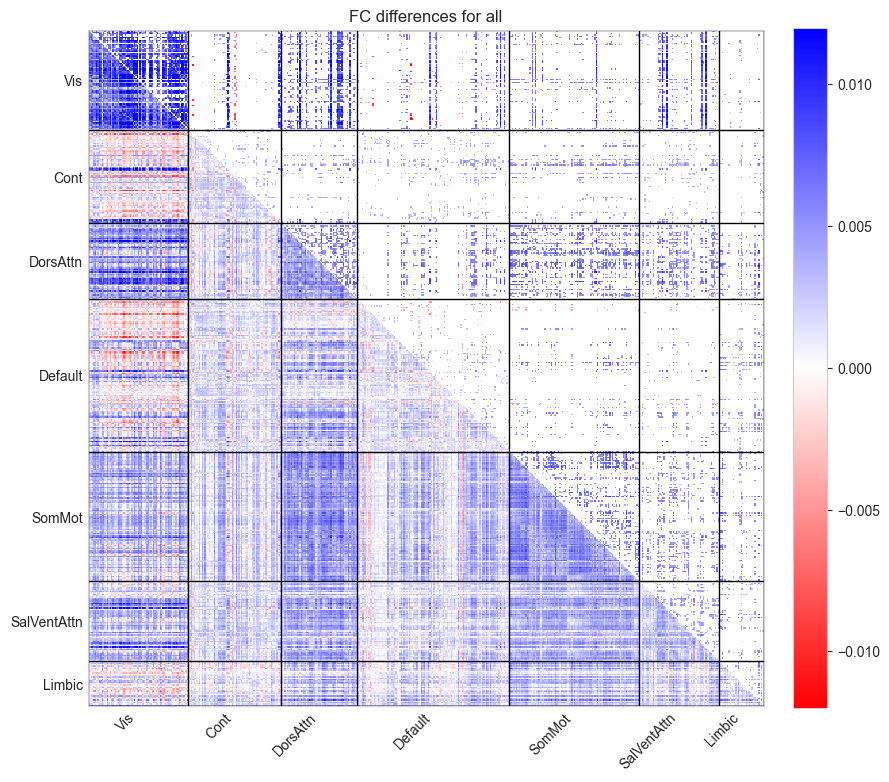

In [5]:
atlas_name = "schaefer500"
# print(idx, atlas_name)

# if atlas_name in ("ho_sub", ):
#     continue
    
if atlas_name in group_map:
    groups = [group_map[atlas_name][lbl] for lbl in atlases_results[atlas_name]["labels"]]
else:
    groups = []


if atlas_name in order_map:
    orders = order_map[atlas_name]
else:
    orders = []

states = atlases_results[atlas_name]["states"]

diff_by_state = {}
perc_change_by_state = {}
for st in states:
    with_z    = states[st]["with_mean"]
    without_z = states[st]["without_mean"]
    diff_by_state[st] = np.tanh(without_z) - np.tanh(with_z)
    perc_change_by_state[st] = (diff_by_state[st] / (np.tanh(without_z) + np.identity(n=1, like=without_z))) * 100


sig_by_state = {}
for st in states:
    ttest_res = states[st]["ttest_res"]
    if isinstance(ttest_res, dict) and st in ttest_res:
        sig_by_state[st] = ttest_res[st]["sig_mat"].astype(bool)
    elif isinstance(ttest_res, dict) and "sig_mat" in ttest_res:
        sig_by_state[st] = ttest_res["sig_mat"].astype(bool)
    else:
        sig_by_state[st] = None

# Shared color limits: symmetric across all panels
all_vals = np.concatenate([
    np.abs(np.asarray(diff_by_state[st])[~np.eye(len(diff_by_state[st]),dtype=bool)])
    for st in states
])
vmax = np.nanmax(all_vals) if all_vals.size else 1.0
vlim_shared = (-vmax, vmax)
cmap="bwr_r"
state = "all"
_, _, im, order, names_ord = plot_grouped_matrix(
    diff_by_state[state],
    groups=groups,  # keep your existing groups variable
    group_order=orders,
    roi_names=atlases_results[atlas_name]["labels"],
    vlim=diff_by_state[state][~np.isnan(diff_by_state[state])].max(),
    # title=f"{state}: Δ r (Raw − Clean)",
    hide_diagonal=True,
    cmap=cmap,
    # ax=axes[idx],
    sig_mask=sig_by_state[state],
    upper_triangle_masked=True,
    show_colorbar=True,
    rank=False,
)
plt.title(f"FC differences for {state}")
plt.tight_layout()
plt.savefig(f"/Users/zach/2025_RA/matthias/final images/FC/FC_diff_{state}_n.svg", dpi=300)
# cbar.set_label("Δ r (Raw − Clean)")

# idx += 1
# ims.append(im)
# 
# # One shared colorbar
# cbar = plt.colorbar( ax=axes.tolist(), fraction=0.025, pad=0.02)
# cbar.set_label("Δ r (Raw − Clean)")
# plt.show()


In [6]:
groups

['Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'Vis',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'SomMot',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 'DorsAttn',
 '

In [0]:
atlas_name =  "schaefer500"

subject_diff_matrices = {"W": [], "S": []}
for state in subject_diff_matrices:
    with_eds, without_eds, labels = process_matrices(results_dir, atlas_name, state)
    assert with_eds.shape == without_eds.shape
    _, n_roi, _ = with_eds.shape
    assert len(labels) == n_roi, f"Labels {len(labels)} vs n_roi {n_roi}"
    subject_diff_matrices[state] = with_eds - without_eds

wake_subjects = np.load(f"/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/results/schaefer500_conv-and-unconv_W_without_eds_subjects.npy")
sleep_subjects = np.load(f"/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/results/schaefer500_conv-and-unconv_S_without_eds_subjects.npy")
common, wake_idx, sleep_idx = np.intersect1d(
    wake_subjects, sleep_subjects, return_indices=True
)

wake_matched  = subject_diff_matrices["W"][wake_idx]
sleep_matched = subject_diff_matrices["S"][sleep_idx]
with_mean = np.mean(wake_matched, axis=0)
without_mean = np.mean(sleep_matched, axis=0) 
ttest_res = fc_paired_test(wake_matched, sleep_matched, return_mats=True, alternative="two-sided", n_permutations=10000) # Positive means gaze changes FC more in Wake than in Sleep

print(ttest_res["sig_mat"].astype(int).sum())
print("labels", len(labels))
print(with_mean.shape)
print("Background" in labels)

atlases_results.setdefault(atlas_name, {}).setdefault("states", {})["diff"] = {
    "with_mean": with_mean,
    "without_mean": without_mean,
    "ttest_res": ttest_res
}
# atlases_results[atlas_name]["labels"] = labels
 


In [ ]:
states[st]["with_mean"]

In [ ]:
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

for i, state in enumerate(["W", "S"]):
    _, _, im, order, names_ord = plot_grouped_matrix(
        -diff_by_state[state],
        groups=groups,  # keep your existing groups variable
        group_order=orders,
        roi_names=atlases_results[atlas_name]["labels"],
        vlim=diff_by_state[state][~np.isnan(diff_by_state[state])].max(),
        # title=f"{state}: Δ r (Raw − Clean)",
        hide_diagonal=True,
        cmap=cmap,
        ax=axs[i],
        sig_mask=sig_by_state[state],
        upper_triangle_masked=True,
        show_colorbar=False,
        rank=True,
    )
    axs[i].set_title(state)
plt.tight_layout()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mat = np.random.uniform(-1, 1, (4, 4))
plt.imshow(mat, cmap=cmap, vmin=-1, vmax=1)
plt.axis("off")
plt.show()

In [ ]:
X = diff_by_state["all"]
X_ranked  = rankdata(X, axis=None).reshape(X.shape)
plt.imshow(X_ranked, cmap="RdBu_r")
plt.colorbar()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
ims = []

idx = 0
for i, atlas_name in enumerate(atlases):
    print(idx, atlas_name)
    
    if atlas_name in ("ho_sub", ):
        continue
        
    if atlas_name in group_map:
        groups = [group_map[atlas_name][lbl] for lbl in atlases_results[atlas_name]["labels"]]
    else:
        groups = []
    
    
    if atlas_name in order_map:
        orders = order_map[atlas_name]
    else:
        orders = []
    
    states = atlases_results[atlas_name]["states"]
    
    diff_by_state = {}
    for st in states:
        with_z    = states[st]["with_mean"]
        without_z = states[st]["without_mean"]
        diff_by_state[st] = np.tanh(without_z) - np.tanh(with_z)
    
    
    sig_by_state = {}
    for st in states:
        ttest_res = states[st]["ttest_res"]
        if isinstance(ttest_res, dict) and st in ttest_res:
            sig_by_state[st] = ttest_res[st]["sig_mat"].astype(bool)
        elif isinstance(ttest_res, dict) and "sig_mat" in ttest_res:
            sig_by_state[st] = ttest_res["sig_mat"].astype(bool)
        else:
            sig_by_state[st] = None
    
    # Shared color limits: symmetric across all panels
    all_vals = np.concatenate([
        np.abs(np.asarray(diff_by_state[st])[~np.eye(len(diff_by_state[st]),dtype=bool)])
        for st in states
    ])
    vmax = np.nanmax(all_vals) if all_vals.size else 1.0
    vlim_shared = (-vmax, vmax)

    _, _, im, order, names_ord = plot_grouped_matrix(
        diff_by_state["all"],
        groups=groups,  # keep your existing groups variable
        group_order=orders,
        roi_names=atlases_results[atlas_name]["labels"],
        vlim=diff_by_state["all"][~np.isnan(diff_by_state["all"])].max(),
        title=atlas_name,
        hide_diagonal=True,
        ax=axes[idx],
        sig_mask=sig_by_state["all"],
        upper_triangle_masked=True,
        show_colorbar=False
    )
    plt.tight_layout()
    idx += 1
    ims.append(im)

# One shared colorbar
cbar = fig.colorbar(ims[0], ax=axes.tolist(), fraction=0.025, pad=0.02)
cbar.set_label("Δ r (Raw − Clean)")
plt.show()
    

In [ ]:
11770 / 124750

In [ ]:
def plot_two_matrices(
    mat1,
    mat2,
    groups,
    group_order,
    roi_names=None,
    cmap="RdBu_r",
    title=None,
    hide_diagonal=True,
    mode="raw",          # "raw" | "rank_joint" | "rank_independent" | "diff"
    diff_vlim=None,      # for mode="diff": scalar -> ±vlim on lower tri difference
    ax=None,
    show_colorbar=False,
):
    """
    Upper triangle: mat2
    Lower triangle: mat1  (or mat1 - mat2 if mode='diff')

    mode:
        'raw'               - raw values, shared colorscale (original behaviour)
        'rank_joint'        - rank both triangles together (shared colorscale)
        'rank_independent'  - rank each triangle independently (pattern comparison,
                              colorbar not meaningful)
        'diff'              - lower = (mat1 - mat2), upper = mat1 raw;
                              use diff_vlim to clip the difference triangle
    """
    N = mat1.shape[0]
    if roi_names is None:
        roi_names = [f"ROI{i}" for i in range(N)]

    grp_rank = {g: i for i, g in enumerate(group_order)}
    default_rank = len(group_order)
    order = sorted(range(N), key=lambda i: (grp_rank.get(groups[i], default_rank), roi_names[i]))
    groups_ord = [groups[i] for i in order]

    mat1_ord = mat1[np.ix_(order, order)].astype(float)
    mat2_ord = mat2[np.ix_(order, order)].astype(float)

    il = np.tril_indices(N, k=-1)
    iu = np.triu_indices(N, k=1)

    M_plot = np.full((N, N), np.nan)

    if mode == "raw":
        M_plot[il] = mat1_ord[il]
        M_plot[iu] = mat2_ord[iu]
        vmin, vmax = None, None

    elif mode == "rank_joint":
        M_plot[il] = mat1_ord[il]
        M_plot[iu] = mat2_ord[iu]
        finite_mask = np.isfinite(M_plot)
        M_ranked = np.full_like(M_plot, np.nan)
        M_ranked[finite_mask] = rankdata(M_plot[finite_mask])
        M_plot = M_ranked
        vmin, vmax = None, None

    elif mode == "rank_independent":
        M_plot[il] = rankdata(mat1_ord[il])
        M_plot[iu] = rankdata(mat2_ord[iu])
        vmin, vmax = None, None

    elif mode == "diff":
        diff = mat1_ord - mat2_ord
        M_plot[il] = diff[il]
        M_plot[iu] = mat1_ord[iu]
        if diff_vlim is not None:
            # clip only the lower triangle difference values
            v = abs(diff_vlim)
            M_plot[il] = np.clip(M_plot[il], -v, v)
        vmin, vmax = None, None

    else:
        raise ValueError(f"Unknown mode: {mode!r}")

    if hide_diagonal:
        np.fill_diagonal(M_plot, np.nan)
    M_masked = np.ma.masked_invalid(M_plot)

    # group bounds
    bounds, centers, labels_out = [], [], []
    for g in group_order:
        idx = [i for i, gg in enumerate(groups_ord) if gg == g]
        if not idx:
            continue
        s, e = min(idx), max(idx) + 1
        bounds.append((s, e, g))
        centers.append((s + e - 1) / 2)
        labels_out.append(g)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
        created_fig = True
    else:
        fig = ax.figure

    ax.grid(False)
    im = ax.imshow(M_masked, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin="upper", interpolation="nearest", aspect="equal")

    for s, e, _ in bounds:
        ax.axhline(e - 0.5, color="k", lw=1)
        ax.axvline(e - 0.5, color="k", lw=1)
    ax.axhline(-0.5, color="k", lw=1); ax.axhline(N - 0.5, color="k", lw=1)
    ax.axvline(-0.5, color="k", lw=1); ax.axvline(N - 0.5, color="k", lw=1)

    ax.set_xticks(centers); ax.set_xticklabels(labels_out, rotation=45, ha="right")
    ax.set_yticks(centers); ax.set_yticklabels(labels_out)
    ax.tick_params(length=0)

    if title:
        ax.set_title(title)

    if show_colorbar:
        label = "rank" if mode in ("rank_joint", "rank_independent") else "Fisher z"
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)

    if created_fig:
        plt.tight_layout()

    return fig, ax, im, order

with_z    = states["all"]["with_mean"]
without_z = states["all"]["without_mean"]
plot_two_matrices(
    with_z,
    without_z,
        groups=groups,  # keep your existing groups variable
        group_order=orders,
    cmap="RdBu_r",
    title=None,
    hide_diagonal=True,
    mode="rank_independent",
    ax=None,
    show_colorbar=False,
        # roi_names=atlases_results[atlas_name]["labels"],
        # vlim=diff_by_state["all"][~np.isnan(diff_by_state["all"])].max(),
        # title="all",
        # hide_diagonal=True,
        # sig_mask=sig_by_state["all"],
        # upper_triangle_masked=True,
        # show_colorbar=True
)

In [ ]:
atlas_name = "schaefer500"

plot_grouped_matrix(
        diff_by_state["all"],
        groups=groups,  # keep your existing groups variable
        group_order=orders,
        roi_names=atlases_results[atlas_name]["labels"],
        vlim=diff_by_state["all"][~np.isnan(diff_by_state["all"])].max(),
        title="all",
        hide_diagonal=True,
        sig_mask=sig_by_state["all"],
        upper_triangle_masked=True,
        show_colorbar=True
    )


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
ims = []

for ax, st in zip(axes, states.keys()):
    _, _, im, order, names_ord = plot_grouped_matrix(
        diff_by_state[st],
        groups=groups,  # keep your existing groups variable
        group_order=orders,
        roi_names=labels,
        vlim=vlim_shared,
        title=f"{st}",
        hide_diagonal=True,
        sig_mask=sig_by_state[st],
        upper_triangle_masked=True,
        ax=ax,
        show_colorbar=False
    )
    ims.append(im)

# One shared colorbar
cbar = fig.colorbar(ims[0], ax=axes.tolist(), fraction=0.025, pad=0.02)
cbar.set_label("Δ r (Without − With)")

In [ ]:
 
label_dict = {i: label for i, label in enumerate(labels)}
# for i, label in enumerate(labels):
    # print(i,label)
df = ttest_res['table']
# neg_t = df[df.t<0]
# neg_t['roi_i_label'] = [label_dict[i] for i in neg_t['roi_i'].values]

# neg_t.loc[:, 'roi_i_label'] = [label_dict[i] for i in neg_t['roi_i'].values]

neg_t = df[df.t > 0].copy()

neg_t['roi_i_label'] = [label_dict[i] for i in neg_t['roi_i'].values]
neg_t['roi_j_label'] = [label_dict[i] for i in neg_t['roi_j'].values]

neg_t.sort_values(by="mean_diff_z", ascending=False)


In [ ]:
def upper_tri_index(n):
    iu = np.triu_indices(n, k=1)
    return iu

def group_tvals_from_fc_stack(fc_stack):
    # fc_stack: (Nsub, R, R)
    nsub, R, _ = np.array(fc_stack).shape
    iu = upper_tri_index(R)
    edges = fc_stack[:, iu[0], iu[1]]  # (Nsub, E)
    # Fisher z for stability
    z = np.arctanh(np.clip(edges, -0.999999, 0.999999))
    tvals, _ = ttest_1samp(z, popmean=0.0, axis=0, nan_policy='omit')
    return tvals  # (E,)

def plot_tval_distributions(fc_by_atlas, bins=80):
    plt.figure(figsize=(8,6))
    for name, stack in fc_by_atlas.items():
        tvals = group_tvals_from_fc_stack(stack)
        plt.hist(tvals, bins=bins, density=True, alpha=0.35, label=name, histtype='stepfilled')
    plt.axvline(0, linestyle='--')
    plt.xlabel("Edgewise group t-values (Fisher z domain)")
    plt.ylabel("Density")
    plt.title("Distribution of edgewise group t-values by atlas")
    plt.legend()
    plt.tight_layout()
    plt.show()


fc_by_atlas = {k: [] for k in atlases if k != "ho_sub"}
labels_by_atlas = {k: [] for k in fc_by_atlas}
labels_img_by_atlas = {k: [] for k in fc_by_atlas}

for k in fc_by_atlas:
    
    atlas_name = k
    
    with_eds, without_eds, labels = process_matrices(atlas_name, state="awake")
    
    with_mean = np.mean(with_eds, axis=0)
    without_mean = np.mean(without_eds, axis=0) 
    
    res_matrices = {"W/O eye diss": np.tanh(without_mean), "With Eye Diss": np.tanh(with_mean), "Difference": np.tanh(without_mean) - np.tanh(with_mean)} 
    fc_by_atlas[k] = (without_eds - with_eds)
    labels_by_atlas[k] = atlases[atlas_name].labels
    labels_img_by_atlas[k] = atlases[atlas_name].maps
# Usage:
plot_tval_distributions(fc_by_atlas)

In [ ]:
from nilearn import image

def voxel_counts_per_label(labels_img):
    lab_img = image.load_img(labels_img)
    data = lab_img.get_fdata().astype(int)
    labels = np.unique(data)
    labels = labels[labels > 0]
    counts = {int(l): int((data == l).sum()) for l in labels}
    return counts  # dict: label_id -> voxel_count

def label_table(labels, counts_dict, min_vox=100):
    rows = []
    # atlas labels array typically has an initial 'Background'; align cautiously:
    # We try to parse numeric label IDs from image; here we assume label ID == index in labels list
    for idx, name in enumerate(labels):
        if idx == 0 or name.lower().startswith('background'):
            continue
        vox = counts_dict.get(idx, 0)
        rows.append({"id": idx, "label": name, "voxels": vox, "is_small(<{})".format(min_vox): vox < min_vox})
    return pd.DataFrame(rows).sort_values("voxels")

def plot_voxel_hist(df, atlas_name, min_vox=100):
    plt.figure(figsize=(7,4))
    plt.hist(df["voxels"].values, bins=40, alpha=0.6)
    plt.axvline(min_vox, linestyle='--')
    small_pct = 100 * (df["voxels"] < min_vox).mean()
    plt.title(f"{atlas_name}: parcel sizes (voxel counts) — {small_pct:.1f}% < {min_vox}")
    plt.xlabel("Voxels")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Example for Juelich / HO / Schaefer:
size_tables = {}
for name, labels_img in labels_img_by_atlas.items():
    counts = voxel_counts_per_label(labels_img)
    df = label_table(labels_by_atlas[name], counts, min_vox=100)
    size_tables[name] = df
    plot_voxel_hist(df, name, min_vox=100)

# Inspect how many Juelich ROIs are <100 voxels:
print(size_tables["juelich"].query("voxels < 100").shape[0], "small parcels in Juelich")

In [ ]:
res_matrices

In [ ]:
 matrix[ttest_res["sig_mat"].astype(bool)].reshape(ttest_res["sig_mat"].shape)

In [ ]:
mapping

In [ ]:
from collections import Counter
from nilearn import image
import nibabel as nib 

schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=500)
atlas_name = "ho"
atlas = atlases[atlas_name]
schaefer_img = nib.load(schaefer.maps)   # integer label image
ho_img = atlas.maps               # integer label image
schaefer_labels = schaefer.labels        # len = 501 (label 0 = background)
ho_labels = atlas.labels[1:]                    # len = K+1


ho_idx_to_lobe = {i: group_map[atlas_name][lbl] for i, lbl in enumerate(ho_labels)}

# 3) Put both atlases on the SAME grid (nearest-neighbor to preserve labels)
ho_resamp_to_schaefer = image.resample_to_img(ho_img, schaefer_img, interpolation="nearest")

s_data = np.asanyarray(schaefer_img.dataobj)          # int labels
h_data = np.asanyarray(ho_resamp_to_schaefer.dataobj) # int labels

# 4) Build a per-voxel lobe array from HO
#    (background -> "Other")
h_lobes = np.empty(h_data.shape, dtype=object)
flat = h_lobes.reshape(-1)
flat_ho = h_data.reshape(-1)
for i in np.unique(flat_ho):
    flat[flat_ho == i] = ho_idx_to_lobe.get(int(i), "Other")

# 5) For each Schaefer parcel, count overlap with HO lobes and assign the max
parcel_to_lobe = {}
parcel_to_counts = {}
s_flat = s_data.reshape(-1)

for idx in range(1, len(schaefer_labels)):  # skip 0 (background)
    vox = (s_flat == idx)
    if not np.any(vox):
        parcel_to_lobe[schaefer_labels[idx]] = "Empty"
        parcel_to_counts[schaefer_labels[idx]] = {}
        continue
    lobes_here = flat[vox]
    counts = Counter(lobes_here)
    # choose the lobe with max overlap (break ties by any deterministic rule)
    chosen = max(counts.items(), key=lambda kv: (kv[1], kv[0]))[0]
    parcel_to_lobe[schaefer_labels[idx]] = chosen
    parcel_to_counts[schaefer_labels[idx]] = dict(counts)

# Example: show a few mappings
for k in list(parcel_to_lobe.keys()):
    print(f"{k:30s} -> {parcel_to_lobe[k]}")


In [ ]:
for  title, matrix in res_matrices.items():
    v_max = max(np.abs(matrix.max()), np.abs(matrix.min()))
    # fig, ax, order = plot_grouped_matrix(matrix, groups, group_order, vlim=v_max, title=title)

    # labels_reordered = [labels[i] for i in order]
    # groups_reordered = [groups[i] for i in order]
    # fc_reordered = matrix[np.ix_(order, order)]
    # print("labels", len(labels))
    # print(matrix.shape)
    # #TODO Do a coarse grained anatomical labelling rather 
    plotting.plot_matrix(
        matrix,
        figure=(10, 8),
        vmax=v_max,
        vmin=-v_max,
        labels=labels,
        title=title,
        reorder=False,
    )
